In [1]:
"""
CNNs with MNIST Dataset + Basic OCR

Goals:
Comparing an MLP with a CNN
Train a CNN
Apply the CNN to an OCR problem

"""

import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# We'll discuss these metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
"""
First step will be to load the MNIST Dataset
What is this data set?
60,000 Training images with Labels and 10,000 Test images with labels
What are the images? Handwritten Digits 0-9 (10 Classes)
Each image is a 28x28 image

Lets load the data and take a look at the shape of the inputs
"""

(X_train_raw, y_train), (X_test_raw, y_test) = tf.keras.datasets.mnist.load_data()

print("X_train_raw shape: ", X_train_raw.shape)
print("y_train shape: ", y_train.shape)
print("X_test_raw shape: ", X_test_raw.shape)
print("y_test shape: ", y_test.shape)
print("Pixel Range: ", X_train_raw.min(), "to", X_train_raw.max())

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train_raw shape:  (60000, 28, 28)
y_train shape:  (60000,)
X_test_raw shape:  (10000, 28, 28)
y_test shape:  (10000,)
Pixel Range:  0 to 255


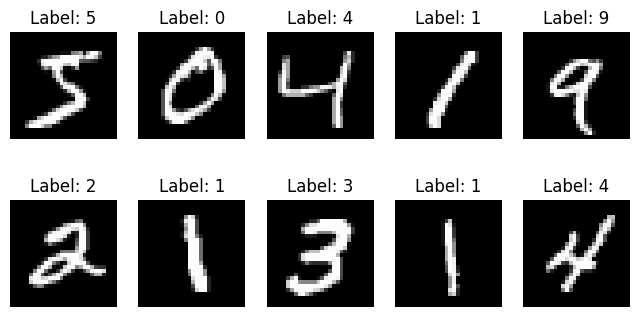

In [3]:
# Let's take a look at some of the data
plt.figure(figsize=(8, 4))
for i in range(10):
  plt.subplot(2, 5, i+1)
  plt.imshow(X_train_raw[i], cmap="gray")
  plt.title(f"Label: {y_train[i]}")
  plt.axis("off")
plt.show()

In [4]:
"""
We need to preprocess our data a little bit
Preprocessing for CNNs is important because they expect a channel value
Channels are color channels, so for normal images they have 3 (RGB), our case
we only have one

Additionally, to keep our weights in check, we'll scale this to 0-1 instead
of 0-255
"""

# Scale
# We could use a MinMaxScaler (converts to 0-1, useful for when you don't
# know the max)
# This also rescales since we know the pixels go from 0-255
X_train = X_train_raw.astype("float32") / 255.0
X_test = X_test_raw.astype("float32") / 255.0

# Reshape our image
# We need to change the shape from (60000, 28, 28) to (60000, 28, 28, 1)
# where 1 is the number of color channels
# Axis = -1 means add a dimension at the end
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

print("CNN Ready Shape for X_train: ", X_train.shape)
print("CNN Ready Shape for X_test", X_test.shape)
print("Pixel Range: ", X_train.min(), "to", X_train.max())

CNN Ready Shape for X_train:  (60000, 28, 28, 1)
CNN Ready Shape for X_test (10000, 28, 28, 1)
Pixel Range:  0.0 to 1.0


In [5]:
"""
Before we try a CNN, let's try to do this with a regular MLP
It can work and it might work in this case because the images are relatively easy
But you lose positional information and things can scale pretty quickly

We'll use a flatten layer to basically convert the entire input into a vector tensor
"""

dense_model = tf.keras.Sequential([
    # Input Layer
    tf.keras.layers.Input(shape=(28,28,1)),
    # Flatten
    tf.keras.layers.Flatten(),
    # Dense Layer
    tf.keras.layers.Dense(128, activation="relu"),
    # Output Layer (10 classes)
    tf.keras.layers.Dense(10, activation="softmax")
])

dense_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=.001),
    loss="sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

"""
What is Spare Categorical Entropy?
This is used for multi-class classification where the labels are integers (i.e 1-10)
How does this differ from regular Categorical Crossentropy?
Categorical Crossentropy is usually used with one-hot encoded vectors
[dog, cat, fish]
One hot encoded vector -> [0,1,0] -> cat is the one "hot" encoded

When to use each?
If you have one-hot vector labels, use regular Categorical Crossentropy
If you have integers (THIS IS OUR CASE), use Sparse Categorical Crossentropy
"""
dense_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
dense_history = dense_model.fit(
    X_train,
    y_train,
    validation_split = .1,
    epochs=3
)

Epoch 1/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9239 - loss: 0.2672 - val_accuracy: 0.9632 - val_loss: 0.1248
Epoch 2/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9648 - loss: 0.1164 - val_accuracy: 0.9705 - val_loss: 0.0994
Epoch 3/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9764 - loss: 0.0801 - val_accuracy: 0.9705 - val_loss: 0.0950


In [7]:
"""
Our Dense model looks like it did pretty well for our images, remember they are
pretty simple, as we get to more complex shapes we'll need something a little
better, enter the Convolutional Neural Network

Architecture
image  -> convolution -> pooling -> convolution -> pooling -> flatten -> dense -> output
"""

cnn_model = tf.keras.Sequential([
    # Input Layer
    # Recall this has the shape of our image 28x28 with 1 color channel
    tf.keras.layers.Input(shape=(28,28,1)),

    # Conv2D Layer
    # What are the parameters for this layer?
    # First is our number of FILTERS
    # Filters are like pattern learners
    # The next piece is a Kernel, specifically Kernel size
    # The Kernel size basically asks how big is the filter window? 3x3
    # Feature Maps are the output of this and will show if a feature is present
    # or not and with what intensity
    tf.keras.layers.Conv2D(32, (3,3), activation="relu"),

    # Max Pooling Layer
    # Shrinks the feature map to only show the strongest feature
    tf.keras.layers.MaxPooling2D((2,2)),

    # Repeat the convolution and pooling to learn more complex features
    # General rule of thumb, as the "image" gets smaller, we'll add more filters
    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2,2)),

    # That should be enough convolutions for this, for more complex images, we'll
    # have more layers
    # Now that we've done that, we pass to a regular MLP
    # We did our convolutions to simplify the image to a series of important
    # features as opposed to various random pixels
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),

    # One other thing I want to introduce
    # Dropout Layer
    # Dropout layers are used to help prevent overfitting
    # During training it will help by setting some inputs randomly equal to zero
    # This helps combat overfitting and memorization by introducing some variety
    # NOTE DROPOUT DOES NOT HAPPEN AFTER TRAINING, IT SPECIFICALLY ONLY HAPPENS THEN
    tf.keras.layers.Dropout(.2),

    # Output layer
    tf.keras.layers.Dense(10, activation="softmax")
    ])

cnn_model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=.001),
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Let's fit the data
# Again, working towards more realistic data models
# We're going to introduce callbacks for early stopping

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    )
]


cnn_history = cnn_model.fit(
    X_train,
    y_train,
    validation_split=.1,
    epochs=5,
    callbacks = callbacks,
    # Batch size basically means how many inputs do I look at before updating
    # the weights, default is 32
    batch_size=128
)

Epoch 1/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9884 - loss: 0.0366 - val_accuracy: 0.9895 - val_loss: 0.0359
Epoch 2/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9897 - loss: 0.0325 - val_accuracy: 0.9902 - val_loss: 0.0327
Epoch 3/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9915 - loss: 0.0268 - val_accuracy: 0.9898 - val_loss: 0.0343
Epoch 4/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9926 - loss: 0.0239 - val_accuracy: 0.9907 - val_loss: 0.0298
Epoch 5/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9919 - loss: 0.0231 - val_accuracy: 0.9908 - val_loss: 0.0333
Epoch 6/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9943 - loss: 0.0180 - val_accuracy: 0.9908 - val_loss: 0.0322


In [10]:
# Evaluate our model on the test set
cnn_loss, cnn_acc = cnn_model.evaluate(X_test, y_test, verbose=0)
print(f"CNN Test Accuracy: {cnn_acc:.4f}")
print(f"CNN Test Loss: {cnn_loss:.4f}")

CNN Test Accuracy: 0.9913
CNN Test Loss: 0.0265


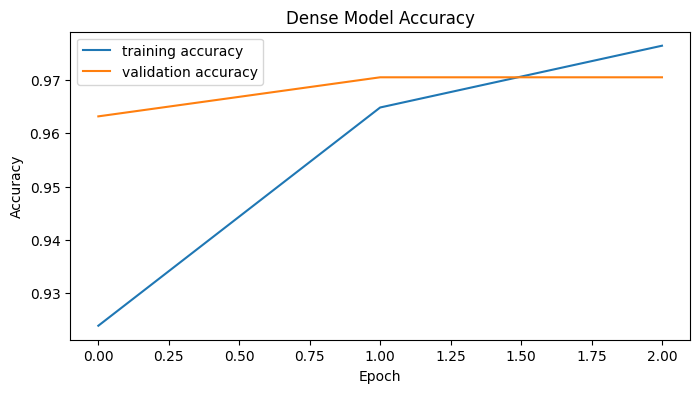

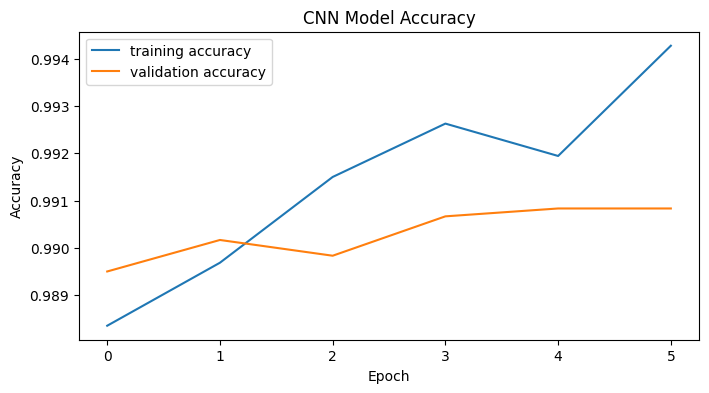

In [11]:
def plot_history(history, title):
    plt.figure(figsize=(8, 4))
    plt.plot(history.history["accuracy"], label="training accuracy")
    plt.plot(history.history["val_accuracy"], label="validation accuracy")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

plot_history(dense_history, "Dense Model Accuracy")
plot_history(cnn_history, "CNN Model Accuracy")

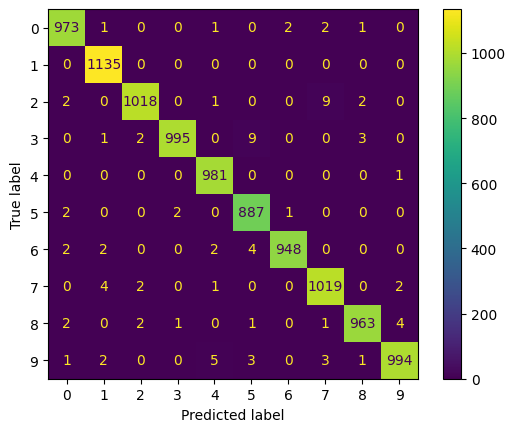

In [13]:
y_prob = cnn_model.predict(X_test, verbose=0)
# Assign it a proper value
# [.1, .4, .3, .2] -> 1 (2nd position)
y_pred = np.argmax(y_prob, axis = 1)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

Number of mistakes: 87


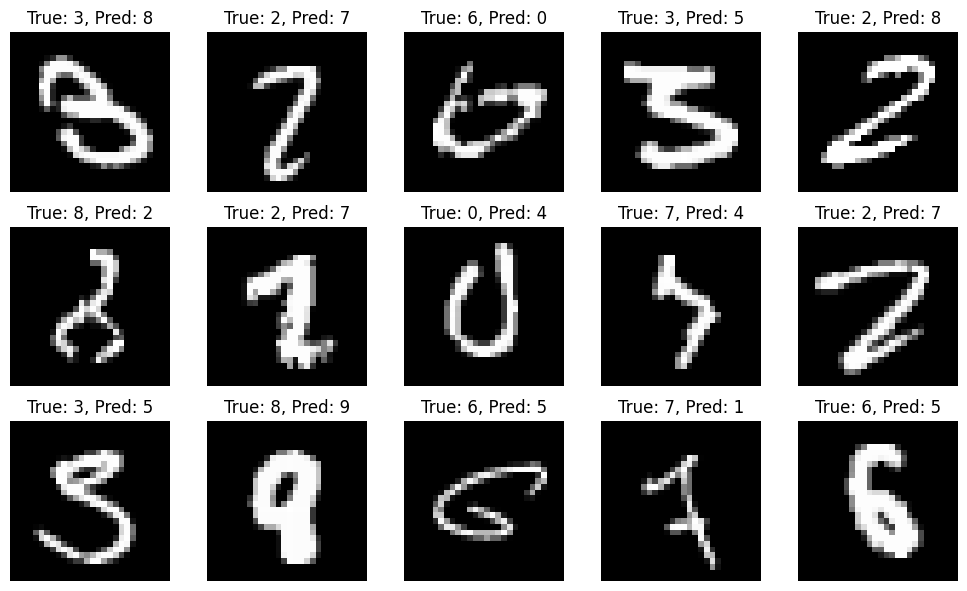

In [16]:
""" Visualizing Mistakes
We can use the below to show some instances where we misclassified the data to see what the model
predicted vs what it actually was
"""

mistake_indices = np.where(y_pred != y_test)[0]
print("Number of mistakes:", len(mistake_indices))

plt.figure(figsize=(10, 6))
for plot_i, idx in enumerate(mistake_indices[:15]):
    plt.subplot(3, 5, plot_i + 1)
    plt.imshow(X_test[idx].squeeze(), cmap="gray")
    plt.title(f"True: {y_test[idx]}, Pred: {y_pred[idx]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

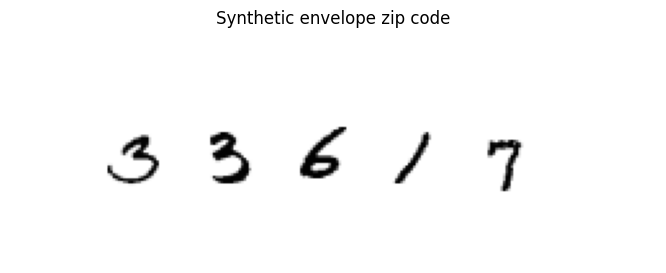

In [21]:
"""
Part 2: Synthetic Zip-Code OCR
A real OCR system needs several pieces:

find the text region
segment/crop each character
preprocess the crop
classify each character
combine predictions
For this teaching demo, we simplify by creating a fake envelope where we already know the digit crop positions.
"""

def pick_mnist_digit_image(digit, x_source, y_source):
    """Return one random MNIST image for a requested digit, normalized to 0-1."""
    candidates = np.where(y_source == digit)[0]
    idx = np.random.choice(candidates)
    return x_source[idx].astype("float32") / 255.0

def create_synthetic_envelope(zip_code="33617", digit_size=28, spacing=8):
    """
    Create a white envelope-like canvas with black handwritten digits.

    MNIST digits are white strokes on black background.
    A paper envelope is closer to black ink on white background.

    We paste black ink by subtracting the MNIST digit stroke intensity from a white canvas.
    """
    height = 90
    width = 40 + len(zip_code) * digit_size + (len(zip_code) - 1) * spacing + 40

    canvas = np.ones((height, width), dtype="float32")  # white page
    crop_boxes = []

    start_x = 35
    start_y = 35

    for i, ch in enumerate(zip_code):
        digit = int(ch)
        mnist_digit = pick_mnist_digit_image(digit, X_test_raw, y_test)

        x0 = start_x + i * (digit_size + spacing)
        y0 = start_y
        x1 = x0 + digit_size
        y1 = y0 + digit_size

        # Black ink on white page: high MNIST stroke value becomes darker on canvas.
        canvas[y0:y1, x0:x1] = np.minimum(canvas[y0:y1, x0:x1], 1.0 - mnist_digit)

        crop_boxes.append((x0, y0, x1, y1))

    return canvas, crop_boxes

envelope, crop_boxes = create_synthetic_envelope("33617")

plt.figure(figsize=(10, 3))
plt.imshow(envelope, cmap="gray", vmin=0, vmax=1)
plt.title("Synthetic envelope zip code")
plt.axis("off")
plt.show()

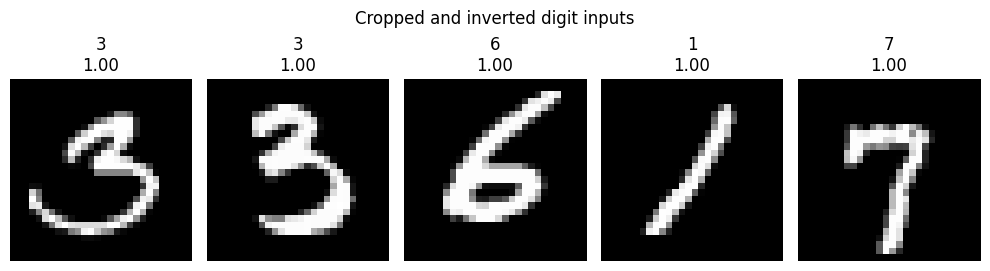

Predicted zip code: 33617


In [22]:
def read_synthetic_zip_code(envelope_image, crop_boxes, model):
    predicted_digits = []

    plt.figure(figsize=(10, 3))

    for i, (x0, y0, x1, y1) in enumerate(crop_boxes):
        crop = envelope_image[y0:y1, x0:x1]

        # IMPORTANT:
        # The model trained on MNIST format: white digit strokes on black background.
        # The envelope has black ink on white background.
        # So we invert it before prediction.
        mnist_like_crop = 1.0 - crop

        model_input = mnist_like_crop.reshape(1, 28, 28, 1)
        probabilities = model.predict(model_input, verbose=0)[0]
        predicted_digit = int(np.argmax(probabilities))
        confidence = float(np.max(probabilities))

        predicted_digits.append(str(predicted_digit))

        plt.subplot(1, len(crop_boxes), i + 1)
        plt.imshow(mnist_like_crop, cmap="gray")
        plt.title(f"{predicted_digit}\n{confidence:.2f}")
        plt.axis("off")

    plt.suptitle("Cropped and inverted digit inputs")
    plt.tight_layout()
    plt.show()

    return "".join(predicted_digits)

predicted_zip = read_synthetic_zip_code(envelope, crop_boxes, cnn_model)
print("Predicted zip code:", predicted_zip)

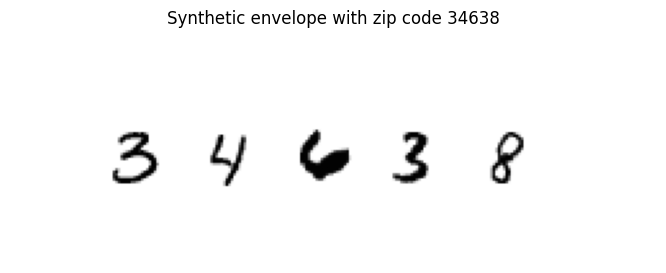

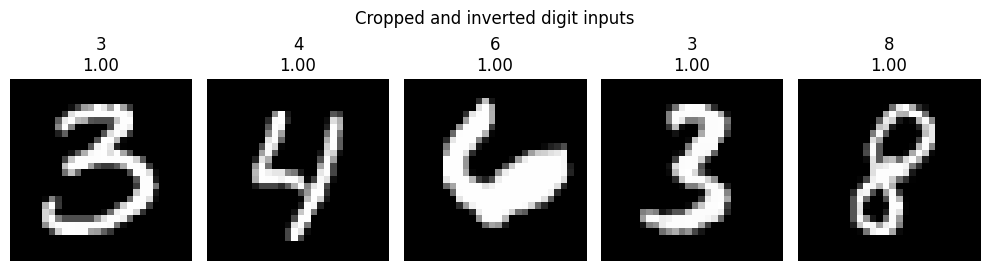

Actual zip code:    34638
Predicted zip code: 34638


In [23]:
test_zip = "34638"
envelope, crop_boxes = create_synthetic_envelope(test_zip)

plt.figure(figsize=(10, 3))
plt.imshow(envelope, cmap="gray", vmin=0, vmax=1)
plt.title(f"Synthetic envelope with zip code {test_zip}")
plt.axis("off")
plt.show()

predicted_zip = read_synthetic_zip_code(envelope, crop_boxes, cnn_model)
print("Actual zip code:   ", test_zip)
print("Predicted zip code:", predicted_zip)